In [1]:
import pandas as pd
from math import ceil
import matplotlib.pyplot as plt

df = pd.read_csv('../../Neuronales_Netz/Fahrradzaehlung_komplett_rolling_mean_int.csv',
                 sep=',')
df['time'] = pd.to_datetime(df['time'])
df['days'] = df['time'].dt.date

df = pd.DataFrame(df.groupby('days')['nordbruecke'].sum())
header = 'nordbruecke'

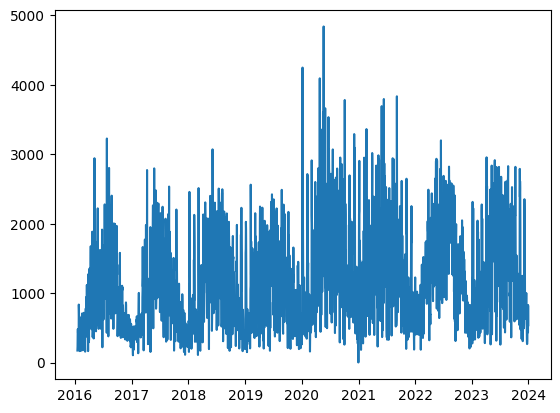

In [2]:
plt.plot(df[header])

In [3]:
df.index = pd.to_datetime(df.index)
type(df.index)

pandas.core.indexes.datetimes.DatetimeIndex

In [4]:
df.index = pd.date_range(start=df.index[0], periods=len(df), freq='D')

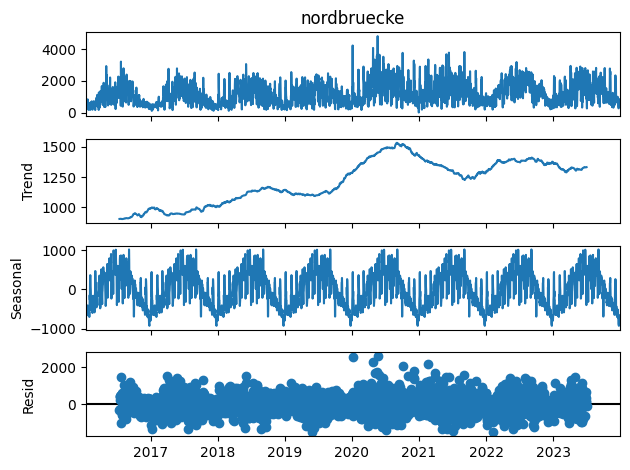

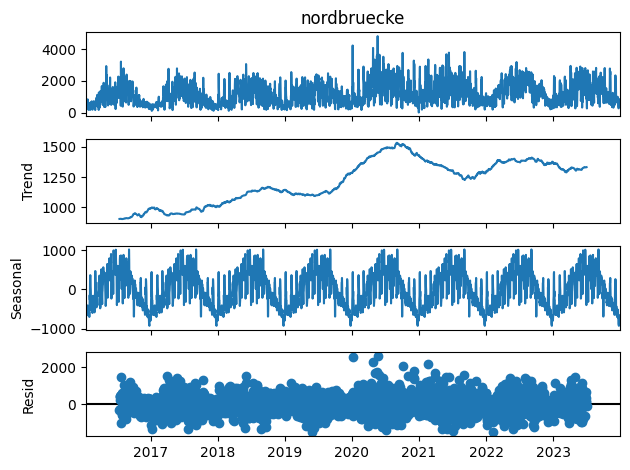

In [5]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(df[header], period=365)
decomposition.plot()

In [6]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df[header])
print("Test statistic = {:.4f}".format(result[0]))
print("p-value = {:.4f}".format(result[1]))

Test statistic = -3.9221
p-value = 0.0019


In [7]:
#probiere logged first differences
from sklearn.preprocessing import MinMaxScaler
import numpy as np
maximum = max(df[header])
scaler = MinMaxScaler(feature_range=(1,maximum))
data = df[[header]]
model=scaler.fit(data)
scaled_data=model.transform(data)
df['scaled'] = scaled_data
df['log'] = np.log(df['scaled'])

In [8]:
#Aufteilung Trainings- und Testdaten

end_train = ceil(len(df) * 0.9)
df_train = df.iloc[:end_train]
df_test = df.iloc[end_train:]

In [9]:
df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)
result = adfuller(df_train['differences'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -7.6327
P-value = 0.0000


C:\Users\caddowallace\AppData\Local\Temp\ipykernel_9372\3224188387.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:,'differences'] = df_train.loc[:,header].diff(periods=365)


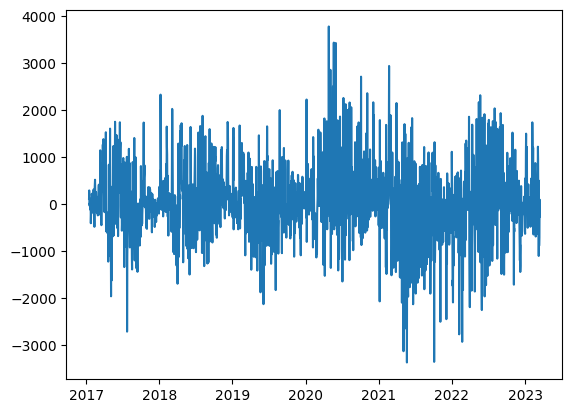

In [10]:
plt.plot(df_train.loc[:,'differences'] )

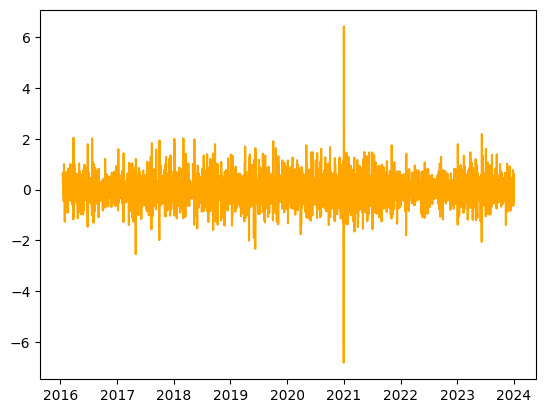

In [11]:
df['first_logged_diff'] = df['log'].diff().dropna()

plt.plot(df['first_logged_diff'], color='orange')
plt.show()

In [12]:
result = adfuller(df['first_logged_diff'].dropna())
print("Test statistic = {:.4f}".format(result[0]))
print("P-value = {:.4f}".format(result[1]))

Test statistic = -20.2572
P-value = 0.0000


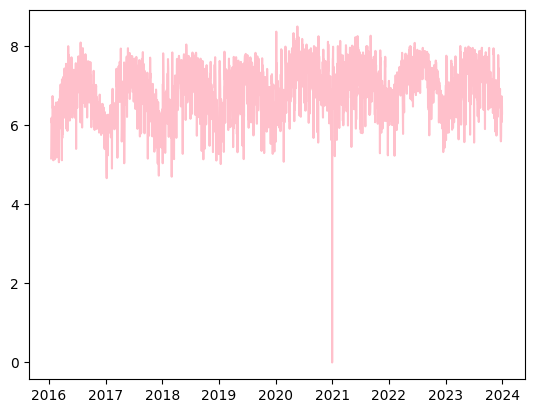

In [13]:
plt.plot(df['log'], color='pink')

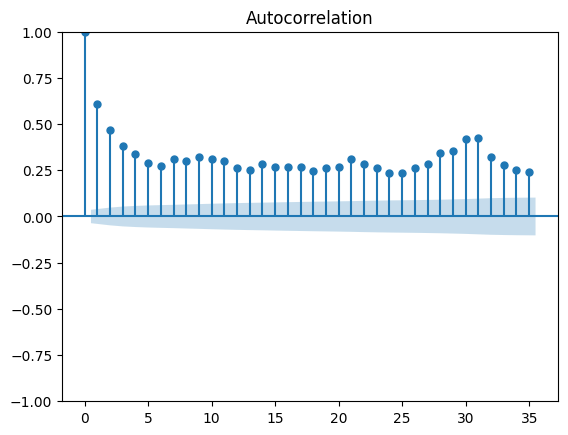

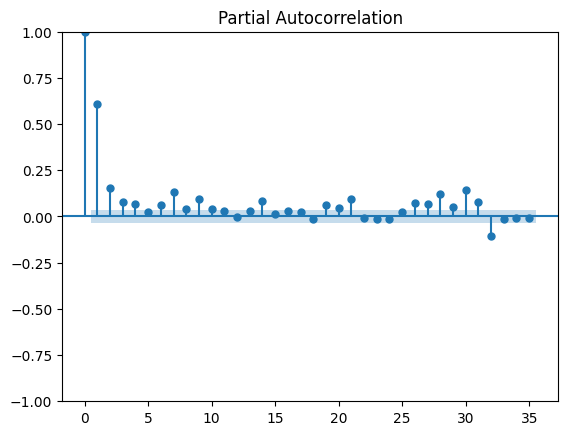

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plot_acf(df[header])
plot_pacf(df[header])
plt.show()

In [15]:
df_train.index = pd.to_datetime(df_train.index)
df_train = df_train.asfreq('D')
df_test = df_test.asfreq('D')

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
start_date= '2023-03-17'
end_date = '2023-12-31'
future_date='2024-02-28'
#Log Likelyhood: hoch, AIC: niedrig



In [16]:
def ma_arima():
    for i in range(1, 7):
        p, d, q = i, 1, 0

        arima = SARIMAX(df_train['log'], order=(p, d, q))
        result = arima.fit()
        #print(result.summary())
        print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
        # Update des DataFrames
        df['differences'] = df_train['differences']
        model = SARIMAX(df['log'], order=(p, d, q))
        result_new = model.filter(result.params)

        # Vorhersage
        predicted = result_new.predict(start=start_date, end=future_date)
        tmp = pd.DataFrame(predicted)
        tmp['crossings'] = tmp['predicted_mean']
        tmp.index = tmp.index.date
        tmp['crossings'] =  np.exp(tmp['crossings'])
        tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

        # Mergen der Daten
        df_r = pd.concat([df_train, tmp], axis=1)
        #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

        df_r[header] = df_r[header].fillna(df_r['crossings'])
        df_r = pd.DataFrame(df_r)
        df_r.index = pd.to_datetime(df_r.index)

        # Plotten
        plt.title('MA, Ordnung = {:.0f}'.format(i))
        plt.plot(df_r.loc[start_date:future_date, header],
             color='orange', label='predicted')
        plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
        plt.legend()
        plt.show()

        y_pred_simple = df_test[header].iloc[:-1]
        y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
        y_pred_simple = y_pred_simple.sort_index().tolist()

        df_test.loc[:,'intervals'] = (df_test[header] > 50).astype(int).diff().fillna(0).ne(0).cumsum()
        df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 50 else '> 10')
        df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
        df_test.loc[:,'simple_predict'] = y_pred_simple

        greater = df_test[df_test['group'] == '> 10']
        mape_arima = []
        mape_simple = []

        for name, group in greater.groupby('intervals'):
            mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
            mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

        mae_arima = np.mean(np.abs(df_test[header] - predicted))
        mse_arima = np.mean(np.square(df_test[header] - predicted))
        mape_arima = sum(mape_arima)/len(mape_arima)
        mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
        mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
        mape_simple = sum(mape_simple)/len(mape_simple)

        print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
        print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
        print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

Log Likelihood: -2076.1380, AIC: 4156.2760


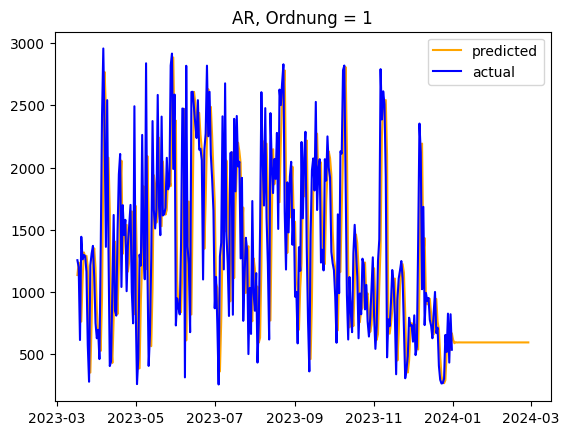

mean absolute error (mae): ARIMA: 1403.7426, simple: 491.3828
mean squared error (mse): ARIMA: 2451129.6482, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4371, simple: 0.4397
Log Likelihood: -2029.2430, AIC: 4064.4861


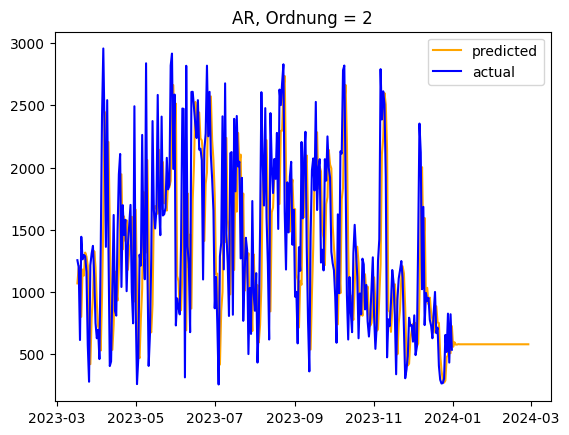

mean absolute error (mae): ARIMA: 1403.7422, simple: 491.3828
mean squared error (mse): ARIMA: 2451159.9837, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4391, simple: 0.4397
Log Likelihood: -1994.1137, AIC: 3996.2274


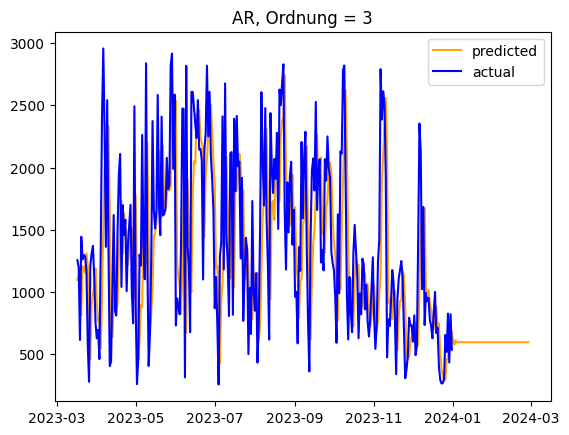

mean absolute error (mae): ARIMA: 1403.7419, simple: 491.3828
mean squared error (mse): ARIMA: 2451172.9375, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4340, simple: 0.4397
Log Likelihood: -1967.9627, AIC: 3945.9255


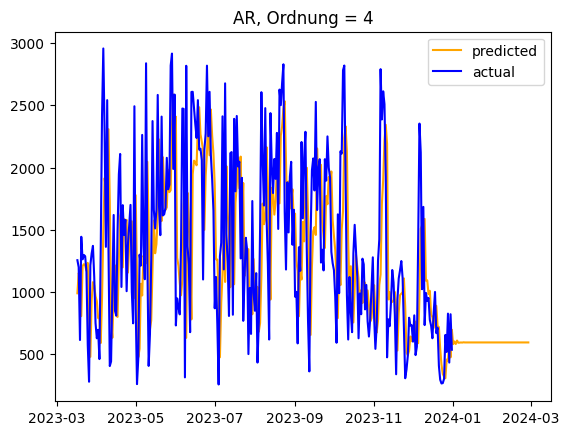

mean absolute error (mae): ARIMA: 1403.7418, simple: 491.3828
mean squared error (mse): ARIMA: 2451193.1031, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4348, simple: 0.4397
Log Likelihood: -1937.5261, AIC: 3887.0522


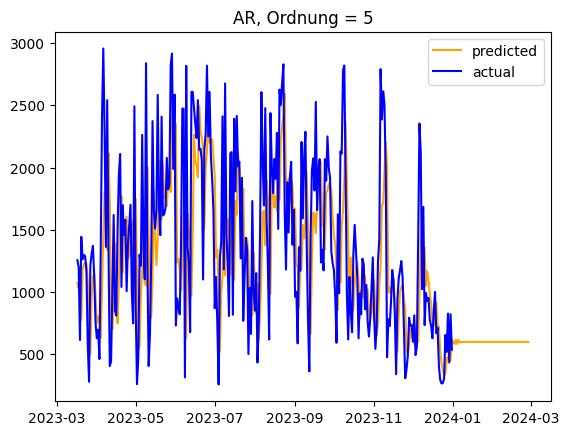

mean absolute error (mae): ARIMA: 1403.7414, simple: 491.3828
mean squared error (mse): ARIMA: 2451207.0894, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4316, simple: 0.4397
Log Likelihood: -1894.8686, AIC: 3803.7371


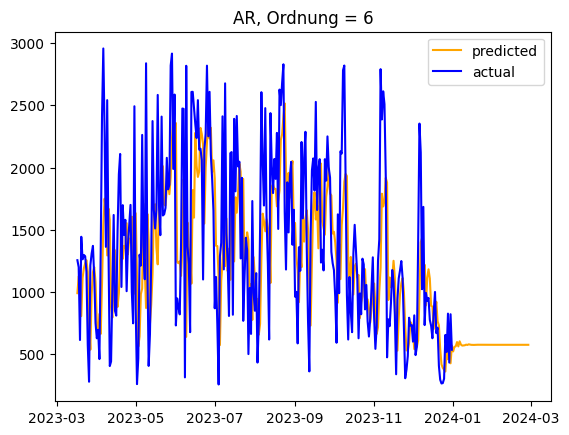

mean absolute error (mae): ARIMA: 1403.7406, simple: 491.3828
mean squared error (mse): ARIMA: 2451204.7649, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4125, simple: 0.4397
Log Likelihood: -1888.8653, AIC: 3793.7306


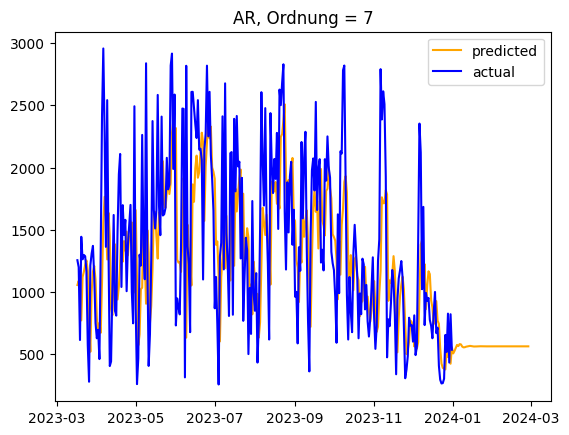

mean absolute error (mae): ARIMA: 1403.7400, simple: 491.3828
mean squared error (mse): ARIMA: 2451203.6754, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4081, simple: 0.4397


In [17]:
for i in range(1, 8):
    p, d, q = i, 1, 0

    arima = SARIMAX(df_train['log'], order=(p, d, q))
    result = arima.fit()
    #print(result.summary())
    print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q))
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start=start_date, end=future_date)
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    tmp['crossings'] =  np.exp(tmp['crossings'])
    tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r.loc[start_date:future_date, header],
         color='orange', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test[header].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test[header] > 50).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 50 else '> 10')
    df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 10']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

In [18]:
df_r

,nordbruecke,scaled,log,differences,predicted_mean,crossings
2016-01-16,173.000000,173.0,5.153292,NaN,NaN,NaN
2016-01-17,230.000000,230.0,5.438079,NaN,NaN,NaN
2016-01-18,442.000000,442.0,6.091310,NaN,NaN,NaN
2016-01-19,483.000000,483.0,6.180017,NaN,NaN,NaN
2016-01-20,425.000000,425.0,6.052089,NaN,NaN,NaN
...,...,...,...,...,...,...
2024-02-24,564.192818,NaN,NaN,NaN,6.335396,564.192818
2024-02-25,564.192400,NaN,NaN,NaN,6.335395,564.192400
2024-02-26,564.192058,NaN,NaN,NaN,6.335395,564.192058
2024-02-27,564.191940,NaN,NaN,NaN,6.335395,564.191940


Log Likelihood: -2076.1380, AIC: 4156.2760


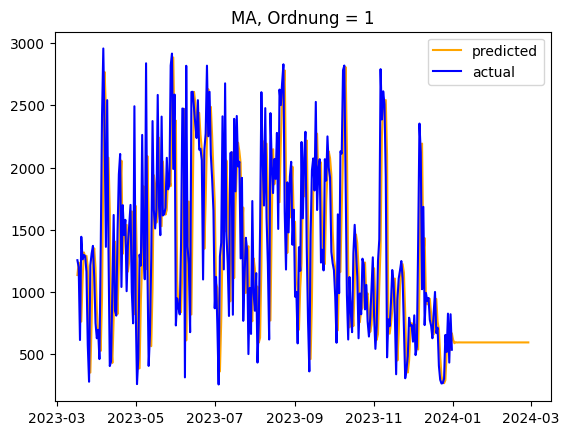

mean absolute error (mae): ARIMA: 1403.7426, simple: 491.3828
mean squared error (mse): ARIMA: 2451129.6482, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4371, simple: 0.4397
Log Likelihood: -2029.2430, AIC: 4064.4861


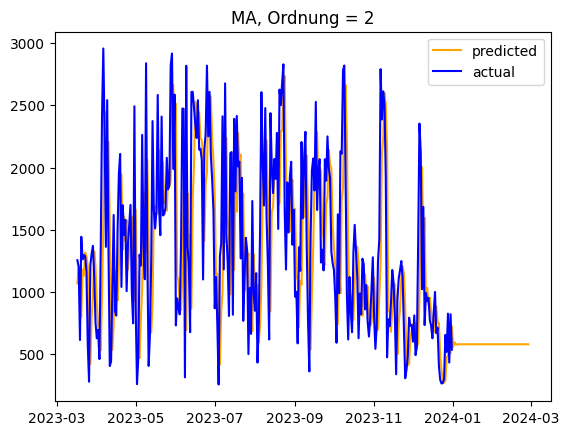

mean absolute error (mae): ARIMA: 1403.7422, simple: 491.3828
mean squared error (mse): ARIMA: 2451159.9837, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4391, simple: 0.4397
Log Likelihood: -1994.1137, AIC: 3996.2274


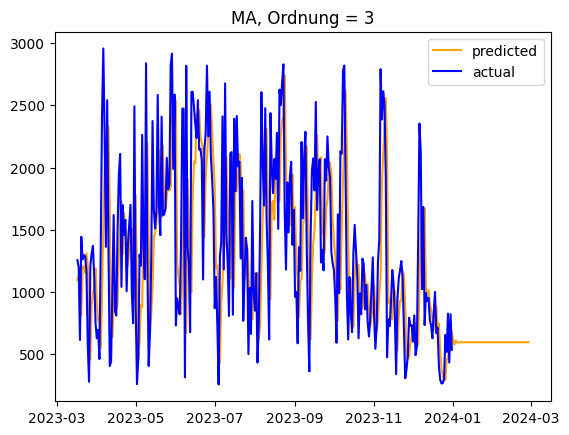

mean absolute error (mae): ARIMA: 1403.7419, simple: 491.3828
mean squared error (mse): ARIMA: 2451172.9375, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4340, simple: 0.4397
Log Likelihood: -1967.9627, AIC: 3945.9255


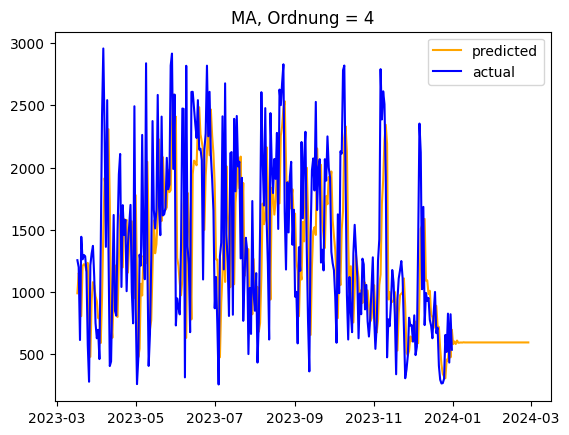

mean absolute error (mae): ARIMA: 1403.7418, simple: 491.3828
mean squared error (mse): ARIMA: 2451193.1031, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4348, simple: 0.4397
Log Likelihood: -1937.5261, AIC: 3887.0522


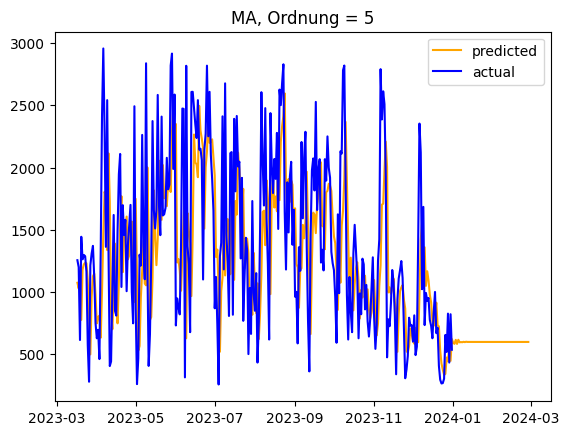

mean absolute error (mae): ARIMA: 1403.7414, simple: 491.3828
mean squared error (mse): ARIMA: 2451207.0894, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4316, simple: 0.4397
Log Likelihood: -1894.8686, AIC: 3803.7371


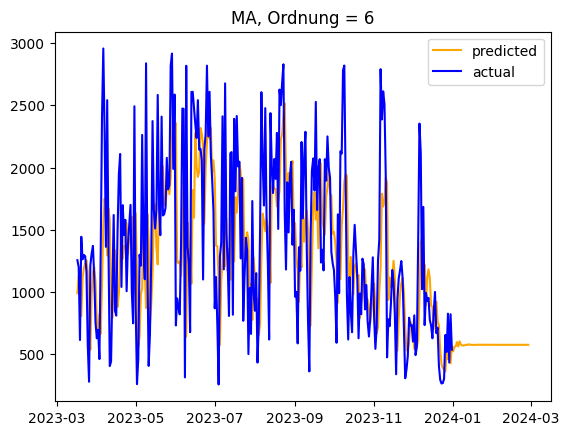

mean absolute error (mae): ARIMA: 1403.7406, simple: 491.3828
mean squared error (mse): ARIMA: 2451204.7649, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4125, simple: 0.4397


In [19]:
ma_arima()

Log Likelihood: -1829.6140, AIC: 3665.2279


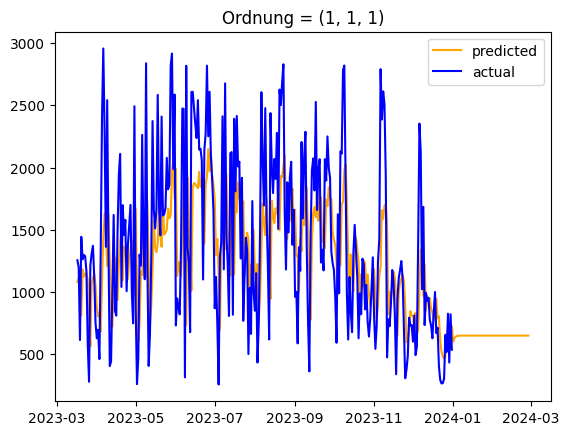

mean absolute error (mae): ARIMA: 1403.7294, simple: 491.3828
mean squared error (mse): ARIMA: 2451222.4190, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4167, simple: 0.4397
Log Likelihood: -1827.9160, AIC: 3663.8320


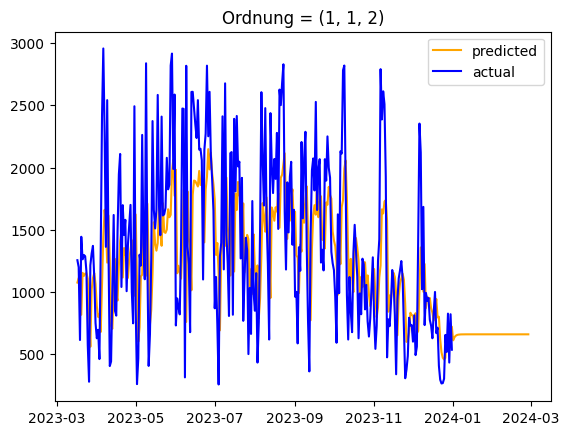

mean absolute error (mae): ARIMA: 1403.7299, simple: 491.3828
mean squared error (mse): ARIMA: 2451221.9791, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4177, simple: 0.4397
Log Likelihood: -1826.3865, AIC: 3662.7731


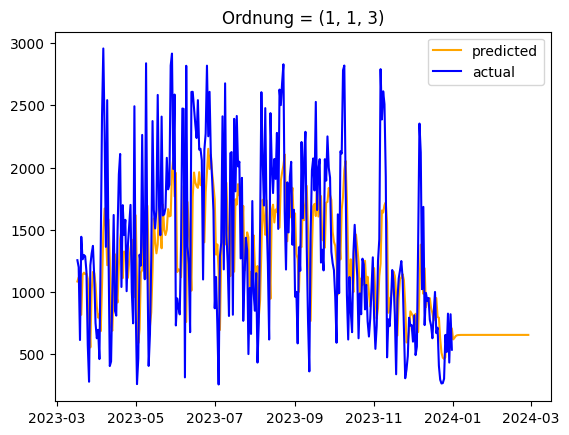

mean absolute error (mae): ARIMA: 1403.7297, simple: 491.3828
mean squared error (mse): ARIMA: 2451219.9187, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4168, simple: 0.4397
Log Likelihood: -1825.9103, AIC: 3663.8206


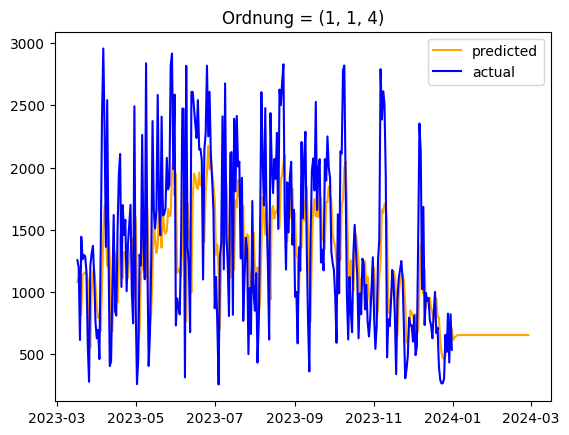

mean absolute error (mae): ARIMA: 1403.7296, simple: 491.3828
mean squared error (mse): ARIMA: 2451220.1297, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4173, simple: 0.4397
Log Likelihood: -1825.1847, AIC: 3664.3694


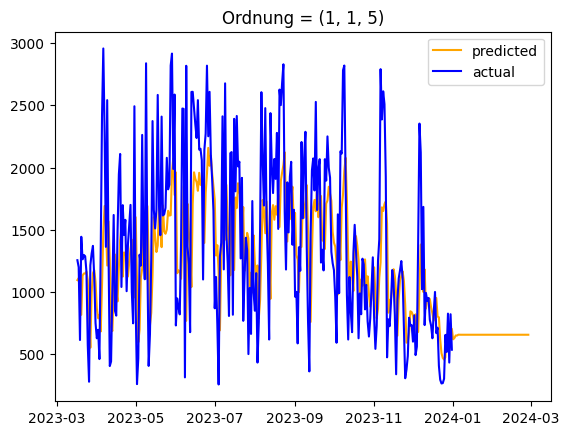

mean absolute error (mae): ARIMA: 1403.7297, simple: 491.3828
mean squared error (mse): ARIMA: 2451218.5701, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4165, simple: 0.4397
Log Likelihood: -1825.2496, AIC: 3666.4991


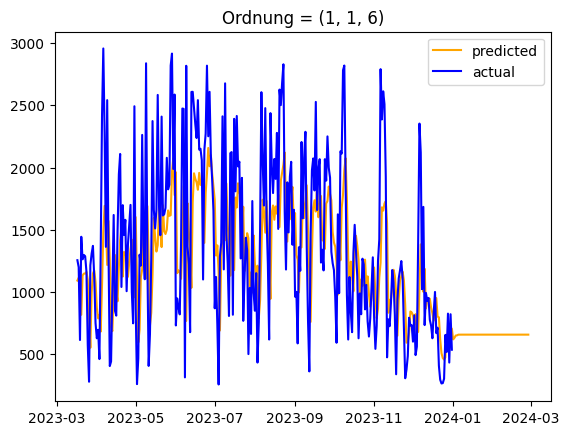

mean absolute error (mae): ARIMA: 1403.7297, simple: 491.3828
mean squared error (mse): ARIMA: 2451218.4942, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4165, simple: 0.4397
Log Likelihood: -1818.6672, AIC: 3655.3345


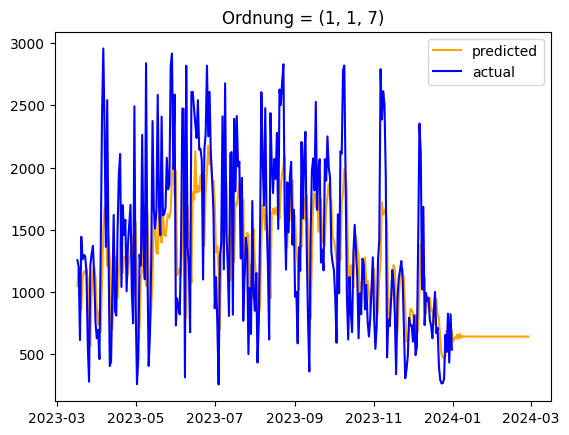

mean absolute error (mae): ARIMA: 1403.7291, simple: 491.3828
mean squared error (mse): ARIMA: 2451214.6635, simple: 433068.2793
mean absolute percentage error (mape): ARIMA: 0.4131, simple: 0.4397


In [20]:
for i in range(1, 8):
    p, d, q = 1, 1, i

    arima = SARIMAX(df_train['log'], order=(p, d, q))
    result = arima.fit()
    #print(result.summary())
    print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))
    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q))
    result_new = model.filter(result.params)

    # Vorhersage
    predicted = result_new.predict(start=start_date, end=future_date)
    tmp = pd.DataFrame(predicted)
    tmp['crossings'] = tmp['predicted_mean']
    tmp.index = tmp.index.date
    tmp['crossings'] =  np.exp(tmp['crossings'])
    tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    #df_r = df_train.merge(tmp, how='left', left_index=True, right_index=True)

    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r = pd.DataFrame(df_r)
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('Ordnung = (1, 1, {:.0f})'.format(i))
    plt.plot(df_r.loc[start_date:future_date, header],
         color='orange', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()

    y_pred_simple = df_test[header].iloc[:-1]
    y_pred_simple = pd.concat([y_pred_simple, df_train[header].iloc[-1:]])
    y_pred_simple = y_pred_simple.sort_index().tolist()

    df_test.loc[:,'intervals'] = (df_test[header] > 50).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:,'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 50 else '> 10')
    df_test.loc[:,'predicted'] = df_r.loc[start_date:end_date, header]
    df_test.loc[:,'simple_predict'] = y_pred_simple

    greater = df_test[df_test['group'] == '> 10']
    mape_arima = []
    mape_simple = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))
        mape_simple.append(mean_absolute_percentage_error(group[header], group['simple_predict']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima)/len(mape_arima)
    mae_simple = np.mean(np.abs(df_test[header] - y_pred_simple))
    mse_simple = np.mean(np.square(df_test[header] - y_pred_simple))
    mape_simple = sum(mape_simple)/len(mape_simple)

    print("mean absolute error (mae): ARIMA: {:.4f}, simple: {:.4f}".format(mae_arima, mae_simple))
    print("mean squared error (mse): ARIMA: {:.4f}, simple: {:.4f}".format(mse_arima, mse_simple))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}, simple: {:.4f}".format(mape_arima, mape_simple))

Log Likelihood: -2076.1380, AIC: 4156.2760
[[615.94607296 589.32049943 597.77032987 595.03490361 595.91480588
  595.63118595 595.72254499 595.69311033 595.70259313 595.69953804
  595.7005223  595.7002052  595.70030736 595.70027445 595.70028505
  595.70028163 595.70028274 595.70028238 595.7002825  595.70028246
  595.70028247 595.70028247 595.70028247 595.70028247 595.70028247
  595.70028247 595.70028247 595.70028247 595.70028247 595.70028247
  595.70028247 595.70028247 595.70028247 595.70028247 595.70028247
  595.70028247 595.70028247 595.70028247 595.70028247 595.70028247
  595.70028247 595.70028247 595.70028247 595.70028247 595.70028247
  595.70028247 595.70028247 595.70028247 595.70028247 595.70028247
  595.70028247 595.70028247 595.70028247 595.70028247 595.70028247
  595.70028247 595.70028247 595.70028247 595.70028247 595.70028247
  595.70028247 595.70028247 595.70028247 595.70028247 595.70028247
  595.70028247 595.70028247 595.70028247 595.70028247 595.70028247
  595.70028247 595.

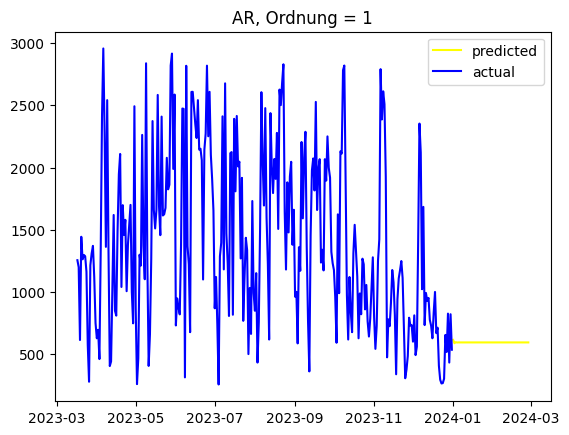

Log Likelihood: -2029.2430, AIC: 4064.4861
[[560.61588938 597.33044163 578.3159958  578.58973916 582.00787698
  580.64599918 580.5246184  580.82637983 580.73368035 580.71250893
  580.7380061  580.73222312 580.72965061 580.7317203  580.73141115
  580.73114101 580.7313024  580.73129134 580.73126528 580.73127733
  580.73127761 580.73127524 580.73127609 580.73127621 580.73127601
  580.73127606 580.73127608 580.73127606 580.73127607 580.73127607
  580.73127607 580.73127607 580.73127607 580.73127607 580.73127607
  580.73127607 580.73127607 580.73127607 580.73127607 580.73127607
  580.73127607 580.73127607 580.73127607 580.73127607 580.73127607
  580.73127607 580.73127607 580.73127607 580.73127607 580.73127607
  580.73127607 580.73127607 580.73127607 580.73127607 580.73127607
  580.73127607 580.73127607 580.73127607 580.73127607 580.73127607
  580.73127607 580.73127607 580.73127607 580.73127607 580.73127607
  580.73127607 580.73127607 580.73127607 580.73127607 580.73127607
  580.73127607 580.

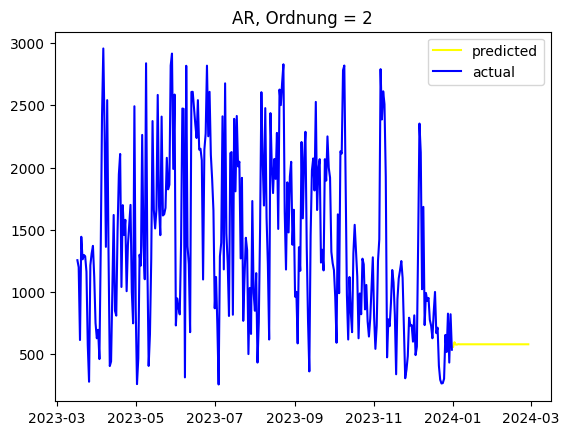

Log Likelihood: -1994.1137, AIC: 3996.2274
[[606.20324197 578.00979256 612.9437392  593.5941284  597.3678992
  594.89276409 598.08598021 596.76809982 596.91676226 596.66438266
  596.94583655 596.86841151 596.87111989 596.84353424 596.86686037
  596.86367664 596.863651   596.86066021 596.86242089 596.86244521
  596.86248183 596.86217399 596.86228809 596.86231194 596.86232367
  596.86229429 596.86229961 596.86230285 596.86230496 596.86230241
  596.86230241 596.86230271 596.862303   596.86230281 596.86230276
  596.86230278 596.86230282 596.8623028  596.8623028  596.8623028
  596.8623028  596.8623028  596.8623028  596.8623028  596.8623028
  596.8623028  596.8623028  596.8623028  596.8623028  596.8623028
  596.8623028  596.8623028  596.8623028  596.8623028  596.8623028
  596.8623028  596.8623028  596.8623028  596.8623028  596.8623028
  596.8623028  596.8623028  596.8623028  596.8623028  596.8623028
  596.8623028  596.8623028  596.8623028  596.8623028  596.8623028
  596.8623028  596.8623028 

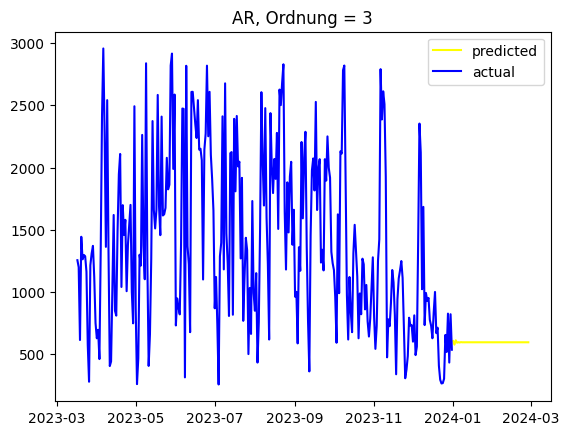

Log Likelihood: -1967.9627, AIC: 3945.9255
[[581.95679991 603.27958424 582.870897   610.84855306 592.85592945
  594.16489226 595.38429534 594.48430245 596.74439427 595.5597982
  595.45842423 595.46763871 595.43612109 595.63617591 595.57012558
  595.54751258 595.53644024 595.53416915 595.55261164 595.55084422
  595.54841213 595.54622055 595.54566602 595.54731964 595.54758322
  595.5474273  595.54713262 595.5470147  595.54714761 595.54721036
  595.54721259 595.54718092 595.54716153 595.5471697  595.54717836
  595.54718099 595.5471783  595.54717566 595.54717578 595.5471767
  595.54717723 595.54717708 595.54717677 595.5471767  595.54717678
  595.54717685 595.54717686 595.54717683 595.54717681 595.54717682
  595.54717683 595.54717683 595.54717683 595.54717682 595.54717682
  595.54717682 595.54717682 595.54717682 595.54717682 595.54717682
  595.54717682 595.54717682 595.54717682 595.54717682 595.54717682
  595.54717682 595.54717682 595.54717682 595.54717682 595.54717682
  595.54717682 595.54

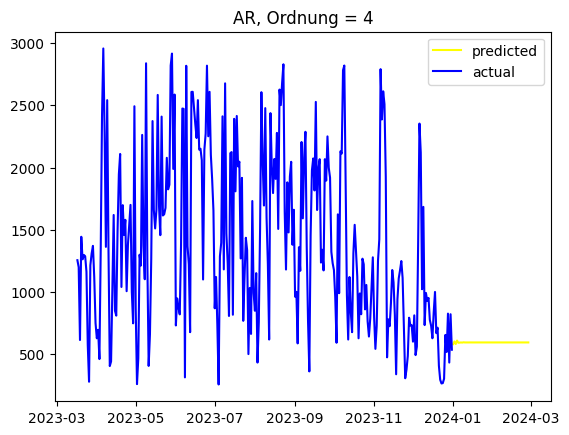

In [21]:
# Test mit forecast() statt predict(). Leider auch kein gutes Ergebnis
for i in range(1,5):
    p, d, q = i, 1, 0

    arima = SARIMAX(df_train['log'], order=(p, d, q))
    result = arima.fit()
    print('Log Likelihood: {:.4f}, AIC: {:.4f}'.format(result.llf, result.aic))

    # Update des DataFrames
    df['differences'] = df_train['differences']
    model = SARIMAX(df['log'], order=(p, d, q))
    result_new = model.filter(result.params)

    forecast_steps = 90  # Anzahl der Schritte zur Vorhersage
    predicted = result_new.forecast(steps=forecast_steps)
    predicted = np.exp(predicted)
    predicted = scaler.inverse_transform([predicted])
    print(predicted)

    tmp = pd.DataFrame(predicted[0], index=pd.date_range(start='2024-01-01', periods=len(predicted[0])), columns=['crossings'])
    print(type(predicted))
    print(tmp)

    #tmp = pd.DataFrame(predicted, columns=['crossings'])
    #tmp.index = pd.date_range(start=end_date, periods=forecast_steps)
    #tmp['crossings'] = np.exp(tmp['crossings'])
    #tmp['crossings'] = scaler.inverse_transform(tmp[['crossings']])

    # Mergen der Daten
    df_r = pd.concat([df_train, tmp], axis=1)
    df_r[header] = df_r[header].fillna(df_r['crossings'])
    df_r.index = pd.to_datetime(df_r.index)

    # Plotten
    plt.title('AR, Ordnung = {:.0f}'.format(i))
    plt.plot(df_r.loc[start_date:future_date, header], color='yellow', label='predicted')
    plt.plot(df.loc[start_date:end_date, header], color='blue', label='actual')
    plt.legend()
    plt.show()
    '''
    # Fehlerberechnung
    df_test.loc[:, 'intervals'] = (df_test[header] > 10).astype(int).diff().fillna(0).ne(0).cumsum()
    df_test.loc[:, 'group'] = df_test[header].apply(lambda x: '≤ 10' if x <= 10 else '> 10')
    df_test.loc[:, 'predicted'] = df_r.loc[start_date:end_date, header]

    greater = df_test[df_test['group'] == '> 10']
    mape_arima = []

    for name, group in greater.groupby('intervals'):
        mape_arima.append(mean_absolute_percentage_error(group[header], group['predicted']))

    mae_arima = np.mean(np.abs(df_test[header] - predicted))
    mse_arima = np.mean(np.square(df_test[header] - predicted))
    mape_arima = sum(mape_arima) / len(mape_arima)

    print("mean absolute error (mae): ARIMA: {:.4f}".format(mae_arima))
    print("mean squared error (mse): ARIMA: {:.4f}".format(mse_arima))
    print("mean absolute percentage error (mape): ARIMA: {:.4f}".format(mape_arima))
    '''
